In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
g=9.81
Ts=0.005
MAX_RANGE = 200.0

In [2]:
class X():
    def __init__(self,state=np.zeros(6)):
        self.x,self.y,self.phi=state[0],state[1],state[2]
        self.xDot,self.yDot,self.phiDot=state[3],state[4],state[5]
    def __call__(self):
        return [self.x,self.y,self.phi,self.xDot,self.yDot,self.phiDot]




In [3]:
class Obstacle:
    def __init__(self,x,y,r):
        self.c=np.array([x,y])
        self.r=r
    def CheckCollisionThroughTime(self,state):
        nChecks=state.shape[1]
        for i in range(nChecks):
            currentState=X(state[:,i])
            if self.CheckCollision([currentState.x,currentState.y]):
                return 1
        return 0
    def CheckCollision(self,point,offset=0):
        distance=np.linalg.norm(np.array(point-self.c))
        if distance<=(self.r+offset):
            return 1
    def __call__(self):
        return self.c,self.r
    


In [4]:
from scipy.integrate import solve_ivp
goalWidth=20
XLim=800
floor=0
cieling=450

class Quadcopter:
    def __init__(self, m=0.18, L=0.086, J=1.5e-4):
        self.m, self.L, self.J = m, L, J
        self.g = 9.81
        self.state = X()

    def step(self, action, dt):
        u = np.clip(action, -1.0, 1.0) 
        hover = self.m * self.g
        F = hover * (1 + u[0]) 

        M = u[1] * 0.02

        s = np.array([self.state.x, self.state.y, self.state.phi, 
                      self.state.xDot, self.state.yDot, self.state.phiDot])
        
        # Dynamics
        def f(st, f_val, m_val):
            return np.array([
                st[3], st[4], st[5],
                -(f_val/self.m)*np.sin(st[2]),
                (f_val/self.m)*np.cos(st[2]) - self.g,
                m_val/self.J
            ])

        k1 = f(s, F, M)
        k2 = f(s + 0.5*dt*k1, F, M)
        k3 = f(s + 0.5*dt*k2, F, M)
        k4 = f(s + dt*k3, F, M)
        
        self.state = X(s + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4))

In [5]:
class TimeOptimalNavEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.quad = Quadcopter()
        self.dt = 0.02
        self.max_steps = 4000


        self.bounds = np.array([0, 800, 0, 450])
        self.goal_radius = 25.0


        self.alpha = 20       # shaping strength
        self.R_goal = 150
        self.R_crash = 80


        self.n_lidar = 32
        self.gamma = 0.99

        self.curriculum_stage = 0
        self.max_stage = 5  

        self.stage_goal_max_dist = [80, 150, 300, 800, 800, 800]
        self.stage_num_obstacles = [0, 1, 3, 5, 5, 5]
        
        self.stage_obstacle_radius = [(0, 0), (10, 20), (15, 30), (15, 40), (40, 70), (80, 100)]
        self.action_space = spaces.Box(-1, 1, (2,), np.float32)
        self.observation_space = spaces.Box(-1, 1, (7 + self.n_lidar,), np.float32) #-np.inf, np.inf

    def _get_obs(self):
        s = self.quad.state
        rel = (self.goal - np.array([s.x, s.y])) / 100.0
        vel = np.array([s.xDot, s.yDot]) / 10.0
        ang = np.array([np.sin(s.phi), np.cos(s.phi)])
        ang_vel = np.array([s.phiDot / 5.0])
        lidar = getattr(self, "_last_lidar", self._get_lidar())
        abs_y = np.array([s.y / 450.0])
        return np.concatenate([rel, vel, ang, ang_vel , lidar]).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            np.random.seed(seed)
            
        if hasattr(self, "_last_lidar"):
            del self._last_lidar

        self.steps = 0

        # --- BENCHMARK OVERRIDE ---
        if options is not None and options.get("is_benchmark", False):
            self.start = np.array(options["start"])
            self.goal = np.array(options["goal"])
            self.obstacles = options["obstacles"]
            
            self.quad.state = X(np.array([self.start[0], self.start[1], 0, 0, 0, 0]))
            self.prev_dist = np.linalg.norm(self.goal - self.start)
            
            return self._get_obs(), {}
            

        # ---------- START POSITION ----------
        self.start = np.random.uniform([50, 50], [750, 400])

        active_stage = np.random.randint(0, self.curriculum_stage + 1)

        max_dist = self.stage_goal_max_dist[active_stage]
        direction = np.random.uniform(-1, 1, size=2)
        direction /= np.linalg.norm(direction) + 1e-8
        
        goal_dist = np.random.uniform(40, max_dist)
        self.goal = self.start + direction * goal_dist
        self.goal = np.clip(self.goal, [50, 50], [750, 400])

        self.quad.state = X(np.array([self.start[0], self.start[1], 0, 0, 0, 0]))
        self.prev_dist = np.linalg.norm(self.goal - self.start)

        # ---------- OBSTACLES ----------
        n_obs = self.stage_num_obstacles[active_stage]
        r_min, r_max = self.stage_obstacle_radius[active_stage]

        for attempt in range(20):
            self.obstacles = []
            
            for _ in range(n_obs):
                for _ in range(50):  
                    c = np.random.uniform([80, 80], [720, 370])
                    r = np.random.uniform(r_min, r_max)

                    if (
                        np.linalg.norm(c - self.start) > 80 and
                        np.linalg.norm(c - self.goal) > 80
                    ):
                        self.obstacles.append(Obstacle(c[0], c[1], r))
                        break
            
            if self._is_path_possible(self.start, self.goal, self.obstacles):
                break

        return self._get_obs(), {}

    def _get_lidar(self):

        s = self.quad.state
        angles = np.linspace(0, 2*np.pi, self.n_lidar, endpoint=False) + s.phi
        rays = np.stack([np.cos(angles), np.sin(angles)], axis=1) # Shape (32, 2)

        origin = np.array([s.x, s.y])
        max_range = 200.0
        dists = np.full(self.n_lidar, max_range)
   
        with np.errstate(divide='ignore'):
            t_x0 = (0 - origin[0]) / rays[:, 0]
            t_x1 = (800 - origin[0]) / rays[:, 0]
            t_y0 = (0 - origin[1]) / rays[:, 1] # Floor
            t_y1 = (450 - origin[1]) / rays[:, 1] # Ceiling
            
        # Filter only positive t (forward rays)
        for t_vals in [t_x0, t_x1, t_y0, t_y1]:
            valid = (t_vals > 0) & (t_vals < max_range)
            dists[valid] = np.minimum(dists[valid], t_vals[valid])
       
        
        for obs in self.obstacles:
            oc = origin - obs.c
            b = 2 * (rays @ oc) 
            c = np.dot(oc, oc) - obs.r**2
            disc = b**2 - 4*c # Shape (32,)

            # Boolean mask where intersection is possible
            valid = disc >= 0

            

            if np.any(valid):

                sqrt_disc = np.sqrt(disc[valid])
                t = (-b[valid] - sqrt_disc) / 2
                current_dists = dists[valid]

                improve = (t > 0) & (t < current_dists) & (t < max_range)

                valid_indices = np.where(valid)[0]
                dists[valid_indices[improve]] = t[improve]
        return (dists / max_range).astype(np.float32)


    def step(self, action):

        self.steps += 1
        self.quad.step(action, self.dt)
        s = self.quad.state

        pos = np.array([s.x, s.y])
        dist = np.linalg.norm(self.goal - pos)


        # reward section

        # --- potential function ---

        alpha = 0.05

        reward = -self.dt + alpha * (self.prev_dist - dist)

        self.prev_dist = dist

        terminated = False

        # --- continuous obstacle penalty ---

        lidar = self._get_lidar()         
        min_lidar = np.min(lidar)         
        self._last_lidar = lidar

        safe_radius = 30.0
        max_range = 200.0

        to_goal = (self.goal - pos) / (dist + 1e-6)
        vel = np.array([s.xDot, s.yDot])

        reward += 0.1 * np.dot(vel, to_goal)
        min_dist = min_lidar * max_range

        if min_dist < safe_radius:
            reward -= 2.0 * np.exp(-min_dist / safe_radius)



        # obstacle collision

        for obs in self.obstacles:
            if obs.CheckCollision(pos):
                reward -= self.R_crash
                terminated = True
                break


        # goal
        success = False
        if dist < self.goal_radius:

            reward += self.R_goal
            success=True
            terminated = True


        # crash

        if not (0 <= s.x <= 800 and 0 <= s.y <= 450):

            reward -= self.R_crash

            terminated = True


        truncated = self.steps >= self.max_steps
        info = {"is_success": success}
        return self._get_obs(), reward, terminated, truncated, info

    def _is_path_possible(self, start, goal, obstacles):
        grid_res = 10
        width = int(800 / grid_res)
        height = int(450 / grid_res)
        
        grid = np.ones((width, height), dtype=bool)
        
        drone_radius = 20.0 
        
        for x in range(width):
            for y in range(height):
                point = np.array([x * grid_res + grid_res / 2, y * grid_res + grid_res / 2])
                for obs in obstacles:
                    if np.linalg.norm(point - obs.c) <= (obs.r + drone_radius):
                        grid[x, y] = False
                        break
                        
        start_cell = (int(np.clip(start[0] / grid_res, 0, width-1)), 
                      int(np.clip(start[1] / grid_res, 0, height-1)))
        goal_cell = (int(np.clip(goal[0] / grid_res, 0, width-1)), 
                     int(np.clip(goal[1] / grid_res, 0, height-1)))
                     
        if not grid[start_cell] or not grid[goal_cell]:
            return False 
            
        queue = [start_cell]
        visited = {start_cell}
        directions = [(0,1), (0,-1), (1,0), (-1,0), (1,1), (1,-1), (-1,1), (-1,-1)]
        
        while queue:
            curr = queue.pop(0)
            if curr == goal_cell:
                return True 
                
            for dx, dy in directions:
                nx, ny = curr[0] + dx, curr[1] + dy
                if 0 <= nx < width and 0 <= ny < height:
                    if grid[nx, ny] and (nx, ny) not in visited:
                        visited.add((nx, ny))
                        queue.append((nx, ny))
                        
        return False 

In [6]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np


class SuccessRateCallback(BaseCallback):
    def __init__(self, check_freq=5000, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.success_buffer = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])

        for info in infos:
            if "is_success" in info:
                self.success_buffer.append(info["is_success"])

        if self.n_calls % self.check_freq == 0 and len(self.success_buffer) > 0:
            success_rate = np.mean(self.success_buffer[-100:])
            print(f"\nStep: {self.num_timesteps} | Success rate (last 100): {success_rate:.2f}")

        return True

In [7]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

class CurriculumCallback(BaseCallback):
    def __init__(self, check_freq=5000, success_threshold=0.8, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.success_threshold = success_threshold
        self.success_buffer = []
        
        self.next_check = check_freq 

    def _on_step(self) -> bool:
        dones = self.locals.get("dones", [])
        infos = self.locals.get("infos", [])

        for done, info in zip(dones, infos):
            if done:
                success = False
                if "is_success" in info:
                    success = info["is_success"]
                elif "final_info" in info and "is_success" in info["final_info"]:
                    success = info["final_info"]["is_success"]
                
                self.success_buffer.append(success)

        if self.num_timesteps >= self.next_check:
            self.next_check += self.check_freq
            
            stage = self.training_env.get_attr("curriculum_stage")[0]
            buffer_size = len(self.success_buffer)
            
            success_rate = 0.0
            if buffer_size > 0:
                success_rate = np.mean(self.success_buffer[-100:])
            
            self.logger.record("curriculum/stage", stage)
            self.logger.record("curriculum/success_rate", success_rate)
            
            print(f"\n--- [Curriculum Check @ {self.num_timesteps} steps] ---", flush=True)
            print(f"Stage: {stage} | Eps in Buffer: {buffer_size} | Success Rate: {success_rate:.2f}", flush=True)
            
            if buffer_size >= 100 and success_rate >= self.success_threshold:
                max_stage = self.training_env.get_attr("max_stage")[0]
                
                if stage < max_stage:
                    new_stage = stage + 1
                    self.training_env.set_attr("curriculum_stage", new_stage)
                    print(f">>> BOOM! Promoted to curriculum stage {new_stage} <<<", flush=True)
                    
                    self.success_buffer = []

        return True

In [8]:
from stable_baselines3 import SAC
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecMonitor
def make_env():
    return Monitor(TimeOptimalNavEnv())

env = make_vec_env(make_env, n_envs=16, vec_env_cls=SubprocVecEnv)

env = VecMonitor(env)

policy_kwargs = dict(
    net_arch=[256, 256]
)

model = SAC(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    buffer_size=2_500_000,
    learning_starts=25_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=64,
    gradient_steps=64,
    ent_coef="auto",          # critical for exploration
    policy_kwargs=policy_kwargs,
    verbose=1,
)
callback = CurriculumCallback(check_freq=5000, success_threshold=0.8)
print("Training SAC time-optimal quadrotor...")
#model.learn(total_timesteps=2_500_000, callback=callback)

c:\Users\Nia Touko\anaconda3\Lib\site-packages\stable_baselines3\common\vec_env\vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Using cuda device
Training SAC time-optimal quadrotor...


In [9]:
test_env = TimeOptimalNavEnv()
test_env.curriculum_stage = 5
obs, _ = test_env.reset(seed=1)
for _ in range(10):
    obs, _ = test_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        #action += np.random.normal(0, 0.05, size=action.shape)
        obs, _, done, trunc, info = test_env.step(action)
        done = done or trunc
    print(info["is_success"])

False
False
False
False
False
False
False
False
False
False


In [10]:
#model.save("RLObstacleBase")

In [11]:
'''
env=TimeOptimalNavEnv()
env = TimeOptimalNavEnv()

model=PPO(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.0,
    clip_range=0.2,
)
model.learn(total_timesteps=400000)
    
'''


'\nenv=TimeOptimalNavEnv()\nenv = TimeOptimalNavEnv()\n\nmodel=PPO(\n    "MlpPolicy",\n    env,\n    learning_rate=3e-4,\n    n_steps=2048,\n    batch_size=256,\n    gamma=0.99,\n    gae_lambda=0.95,\n    ent_coef=0.0,\n    clip_range=0.2,\n)\nmodel.learn(total_timesteps=400000)\n    \n'

In [12]:
model=model.load("RLObstacleBase")

39817
Time Taken: 8.86 seconds


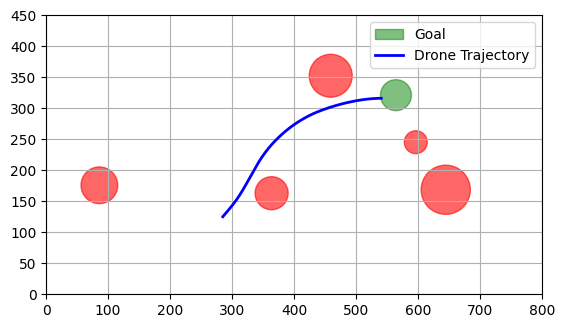

In [24]:
import random as rand
test_env = TimeOptimalNavEnv()
test_env.curriculum_stage = 3
seed=np.random.randint(0,100000)
#seed=21758
#seed=85246
obs, _ = test_env.reset(seed=seed)
print(seed)

#test_env.goal = np.array([750.0, 200.0])
path_x, path_y = [], []
done = False
steps = 0
while not done:
    action, _ = model.predict(obs, deterministic=True)
    #action += np.random.normal(0, 0.05, size=action.shape)

    obs, reward, done, truncated, _ = test_env.step(action)
    done = done or truncated
    path_x.append(test_env.quad.state.x)
    path_y.append(test_env.quad.state.y)
    steps+=1

time_taken = steps * test_env.dt 
print(f"Time Taken: {time_taken:.2f} seconds")
fig, ax = plt.subplots(1)

# goal zone
goal_circle = plt.Circle((test_env.goal[0], test_env.goal[1]), test_env.goal_radius,
                         color="green", alpha=0.5, label="Goal")
ax.add_patch(goal_circle)

# obstacles
for obs in test_env.obstacles:
    circle = plt.Circle((obs.c[0], obs.c[1]), obs.r, color="red", alpha=0.6)
    ax.add_patch(circle)

# trajectory
ax.plot(path_x, path_y, 'b-', linewidth=2, label='Drone Trajectory')

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 800)
ax.set_ylim(0, 450)

plt.legend()
plt.grid(True)
plt.show()

Time Taken: 7.10 seconds


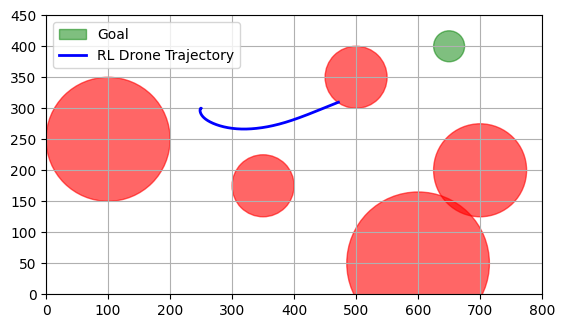

In [14]:
test_env = TimeOptimalNavEnv()

benchmark_options = {
    "is_benchmark": True,
    "start": [250.0, 300.0],         
    "goal": [650.0, 400.0],       
    "obstacles": [
        Obstacle(100,250,100),
        Obstacle(350,175,50),
        Obstacle(500,350,50),
        Obstacle(700,200,75),
        Obstacle(600,50,115)
        #Obstacle(100, 250, 100),
        #Obstacle(300, 250, 75),
        #Obstacle(500, 300, 100),
        #Obstacle(700, 200, 75),
        #Obstacle(600, 50, 115)
    ]
}

#
obs, _ = test_env.reset(seed=1, options=benchmark_options)

path_x, path_y = [], []
done = False
steps = 0

while not done:
    action, _ = model.predict(obs, deterministic=True) 
    obs, reward, done, truncated, _ = test_env.step(action)
    done = done or truncated
    
    path_x.append(test_env.quad.state.x)
    path_y.append(test_env.quad.state.y)
    steps += 1

time_taken = steps * test_env.dt 
print(f"Time Taken: {time_taken:.2f} seconds")

# --- Plotting ---
fig, ax = plt.subplots(1)

goal_circle = plt.Circle((test_env.goal[0], test_env.goal[1]), test_env.goal_radius, color="green", alpha=0.5, label="Goal")
ax.add_patch(goal_circle)

for obs in test_env.obstacles:
    circle = plt.Circle((obs.c[0], obs.c[1]), obs.r, color="red", alpha=0.6)
    ax.add_patch(circle)

ax.plot(path_x, path_y, 'b-', linewidth=2, label='RL Drone Trajectory')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 800)
ax.set_ylim(0, 450)
plt.legend()
plt.grid(True)
plt.show()